**Particle in a 1D Box (finite potential)**

Numerical solution particle in a box with **finite potential barriers** in the box edges.
The code assumed the particle is an electron and we use Atomic Units.

We start importing libraries:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

We define a function with the potential for the Schrödinger Equation. In this case is zero inside the box (that goes from -1 to +1) and different from zero outside. We take a potential of V=4 outside the box as in this Chemistry LibreText example https://chem.libretexts.org/Bookshelves/Physical_and_Theoretical_Chemistry_Textbook_Maps/Quantum_Tutorials_(Rioux)/09%3A_Numerical_Solutions_for_Schrodinger's_Equation/9.05%3A_Particle_in_a_Finite_Potential_Well

*establecemos que V(x)=V0·x*

EN EL SIGUIENTE PASO CALCULO V

In [2]:
#Potential as a function of position
def potencial(x):
    V=2*x
    return V

And now we define a function that calculates the matrix (denoted by F in the theoretical derivation) that encodes the Schrödinger Equation in finite diference form for n points from 0 to n-1

EN EL SIGUIENTE PASO CALCULA Fij

In [3]:
#Discretized Schrodinger equation in n points (FROM 0 to n-1)
def Eq(n,h,x):
    F = np.zeros([n,n])
    for i in range(0,n):
        F[i,i] = -2*((h**2)*potencial(x[i]) + 1)
        if i > 0:
           F[i,i-1] = 1
           if i < n-1:
              F[i,i+1] = 1
    return F

Up to now, the code does nothing explicitly. We have just defined how to calculate the potential and how to calculate the matrix F

Let us now start the numerical solution, entering the parameters that we need: the discretization h and the size of the box. Usaré L=1 por el ejemplo del slated well potential.

In [4]:
# Interval for calculating the wave function
L = 1
xlower = 0
xupper = 1

#Discretization options
h = 0.0002  #discretization in space

#Create coordinates at which the solution will be calculated
x = np.arange(xlower,xupper+h,h)
#grid size (how many discrete points to use in the range [-L/2,L/2])
npoints=len(x)

print("Using",npoints, "grid points.")

Using 5001 grid points.


Now we can calculate F explicitly and diagonalize. The result of the diagonalization is **not ordered** so we have to order the results (energies and wavefunctions) by energy values.

In [5]:
#Calculation of discrete form of Schrodinger Equation and diagonalization
F=Eq(npoints,h,x)
eigenValues, eigenVectors = np.linalg.eig(F)

#Order results by eigenvalue
# w ordered eigenvalues and vs ordered eigenvectors
idx = eigenValues.argsort()[::-1]
w = eigenValues[idx]
vs = eigenVectors[:,idx]

#Energy Level
E = - w/(2.0*h**2)

Print **Energy Results** for the first energy levels:

In [6]:
#Energy Levels
E = - w/(2.0*h**2)
for k in range(0,3):
  print("n=",k,", E(numeric)=%.4f" %E[k])

n= 0 , E(numeric)=5.9242
n= 1 , E(numeric)=20.7341
n= 2 , E(numeric)=45.3972


Note that we have obtained only two energy states that are bound to the box, the third has higher energy than the potential.

Now let us show the Wavefunctions obtained in the diagonalization process

Plotting


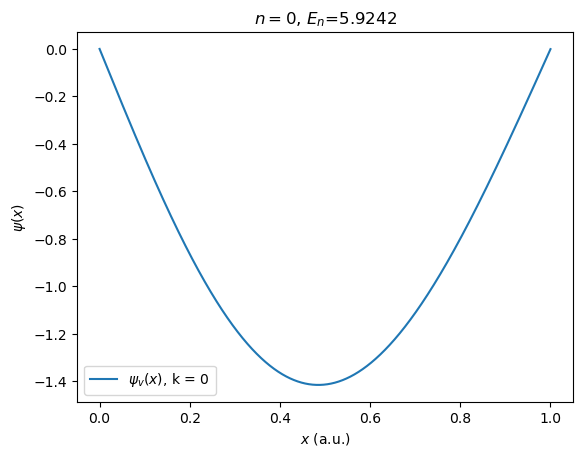

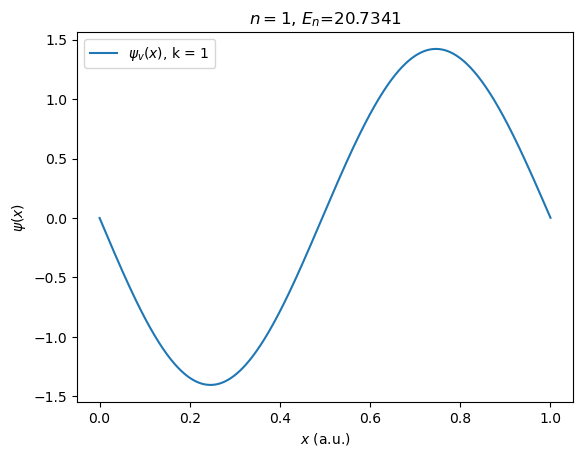

Bye


In [7]:
#Init Wavefunction (empty list with npoints elements)
psi = [None]*npoints

#Calculation of normalised Wave Functions
for k in range(0,len(w)):
	psi[k] = vs[:,k]
	integral = h*np.dot(psi[k],psi[k])
	psi[k] = psi[k]/integral**0.5

#Plot Wave functions
print("Plotting")

#v = int(input("\n Quantum Number (enter 0 for ground state):\n>"))
for v in range(0,2):
	plt.plot(x,psi[v],label=r'$\psi_v(x)$, k = ' + str(v))
	plt.title(r'$n=$'+ str(v) + r', $E_n$=' + '{:.4f}'.format(E[v]))
	plt.legend()
	plt.xlabel(r'$x$ (a.u.)')
	plt.ylabel(r'$\psi(x)$')
	plt.show()

print("Bye")


Cambiando la discretización a valores mas pequeños, podemos ver como la energía se acerca más y mas al valor "preciso", que parece estar alrededor de 5.92. El valor usado de h (0.0002) es el más pequeño que he podido usar. Un valor más pequeño no terminaba de cargar.Note that we have obtained only two energy states that are bound to the box, the third has higher energy than the potential.
